In [ ]:
# %%
import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()

# %%
# Tamaño del dataset

dataset.shape

# %%
# Búsqueda de valores nulos

dataset.isna().sum()

#por ejemnplo

# %%
# Remoción de valores nulos

dataset = dataset.dropna()
dataset.isna().sum()


# %%
# Columna Origin
# Nota:  1) USA
#        2) Europe
#        3) Japan

dataset.Origin.value_counts()

# %%Profe guapo

# Convierte la columna a categorias.
# Nota. Realmente no se debería hacer asi para aplicaciones
# en productivo

dataset["Origin"] = dataset["Origin"].map(
    {   
        1: "USA", 
        2: "Europe", 
        3: "Japan",
    },
)

# %%
# Genera variables dummy para indicar la procedencia (Pésima solución)

dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
dataset.head()

# Note que aca no se usa train_test_split

train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

# Las millas por galon (MPG) son función de las demas variables.

import seaborn as sns

sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde"
)

# %%

# Cálculo de algunas estadísticas generales

train_dataset.describe().transpose()

# %%
# Particionamiento de los datos en features y labels

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

# %%
# Estandarización de los datos (normalización)

train_dataset.describe().transpose()[["mean", "std"]]

# Efecto del StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(
    data=scaler.fit_transform(train_dataset),
    columns=train_dataset.columns,
).describe().transpose()[["mean", "std"]]

# %%
# Regresión lineal con una sola variable (Horsepower)

horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]

horsepower_scaler.fit(train_horsepower)

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)

# %%
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standarized_train_horsepower, train_labels)

# %%

# Intercepto
horsepower_model.intercept_

# Coeficientes
horsepower_model.coef_

# %%
import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)})
x.head()

# %%
# Predicción

scaled_x = horsepower_scaler.transform(x)
y = horsepower_model.predict(scaled_x)
y[:5]


c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ESTEBAN\Documents\GitHub\std-esteban-medina-guayasamin2

array([39.57626034, 39.42115555, 39.26605075, 39.11094596, 38.95584117])

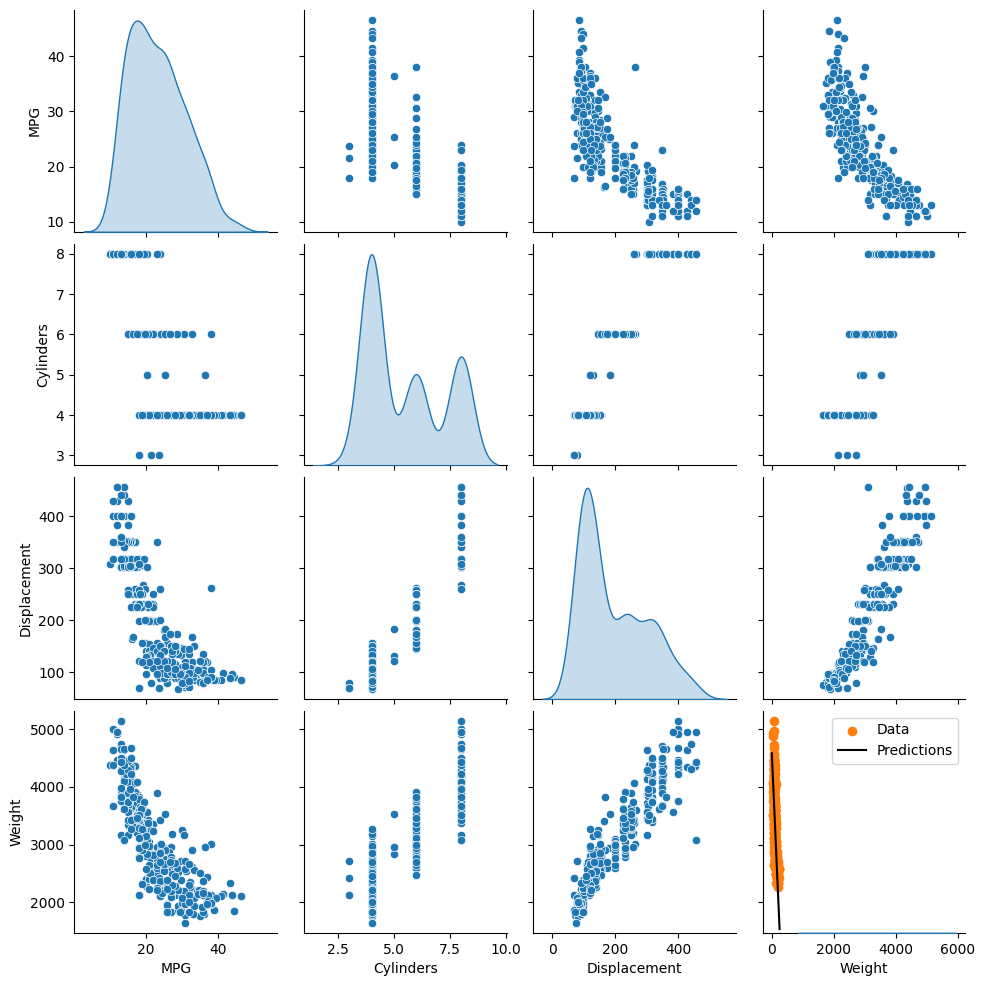

In [3]:

# %%
import matplotlib.pyplot as plt


def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()
    
    
    
    
    

plot_horsepower(x, y)




In [4]:


# Evaluación

from sklearn.metrics import mean_squared_error

test_results = {}

y_pred = horsepower_model.predict(standarized_test_horsepower)

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

test_results


{'horsepower_model': 20.829300555790315}

Clase 3 , 19 de septiembre

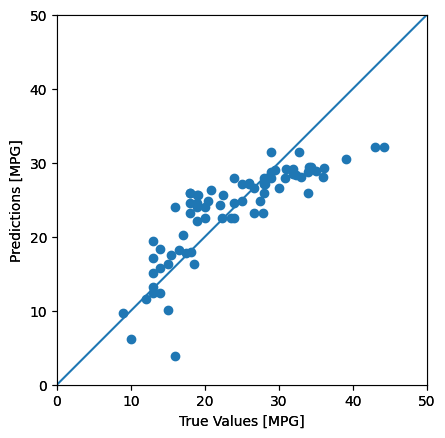

In [5]:
#Regresión lineal con todas las variables

features_scaler = StandardScaler()

features_scaler.fit(train_features)

standarized_train_features = features_scaler.transform(train_features)
standarized_test_features = features_scaler.transform(test_features)

linear_model = LinearRegression()
linear_model.fit(standarized_train_features, train_labels)

# Intercepto
linear_model.intercept_

# Coeficientes
linear_model.coef_

def plot_predictions(y_true, y_pred):

    ax = plt.axes(aspect="equal")
    plt.scatter(y_true, y_pred)
    plt.xlabel("True Values [MPG]")
    plt.ylabel("Predictions [MPG]")
    lims = [0, 50]
    plt.xlim(lims)
    plt.ylim(lims)
    _ = plt.plot(lims, lims)
    
test_predictions = linear_model.predict(standarized_test_features)

plot_predictions(
    y_true=test_labels,
    y_pred=test_predictions,
)    
    
test_results["linear_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=test_predictions,
)

test_results

plot_predictions(
    y_true=test_labels,
    y_pred=horsepower_model.predict(standarized_test_horsepower),
)

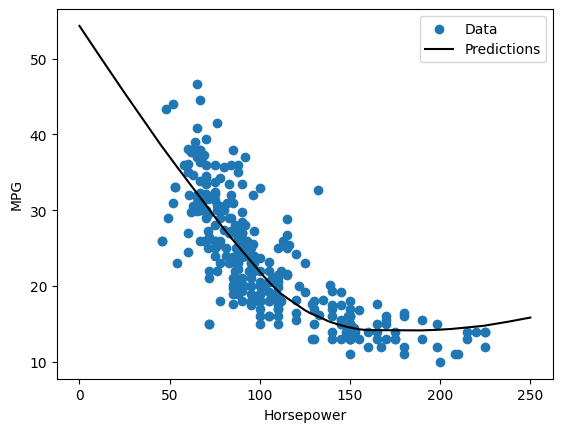

In [6]:
# Red neuronal con una sola entrada (Horsepower)

from sklearn.neural_network import MLPRegressor

mlp_horsepower = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)
mlp_horsepower.fit(standarized_train_horsepower, train_labels)

y = mlp_horsepower.predict(scaled_x)
plot_horsepower(x, y)

In [7]:

y_pred = mlp_horsepower.predict(standarized_test_horsepower)

test_results["mlp_horsepower"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

test_results

{'horsepower_model': 20.829300555790315,
 'linear_model': 10.172092283687606,
 'mlp_horsepower': 12.806525974883078}

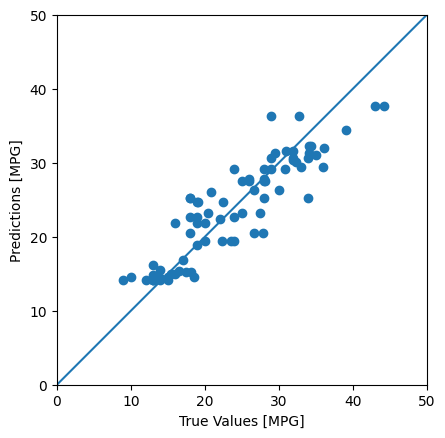

In [8]:
plot_predictions(
    y_true=test_labels,
    y_pred=mlp_horsepower.predict(standarized_test_horsepower),
)

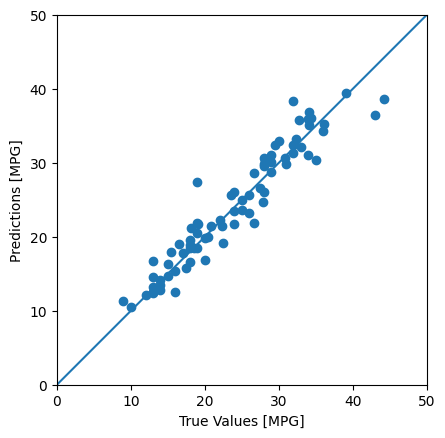

In [11]:
# Red neuronal con todas las variables

mlp = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)

mlp.fit(standarized_train_features, train_labels)

test_predictions = mlp.predict(standarized_test_features)

plot_predictions(
    y_true=test_labels,
    y_pred=test_predictions,
)

In [12]:


test_results["mlp"] = mean_squared_error(
    y_true=test_labels,
    y_pred=test_predictions,
)
# Desempeño de los modelos

pd.DataFrame(test_results, index=["Mean squared error [MPG]"]).T.sort_values(
    by="Mean squared error [MPG]", ascending=False
)

,Mean squared error [MPG]
horsepower_model,20.829301
mlp_horsepower,12.806526
linear_model,10.172092
mlp,5.954689


In [13]:
# almacenamiento de los modelos y del scaler de features

import os
import pickle


with open("../submission/mlp.pkl", "wb") as file:
    pickle.dump(mlp, file)

with open("../submission/features_scaler.pkl", "wb") as file:
    pickle.dump(features_scaler, file)

In [14]:

# Uso del modelo

import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset = dataset.dropna()
dataset["Origin"] = dataset["Origin"].map(
    {1: "USA", 2: "Europe", 3: "Japan"},
)
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
y_true = dataset.pop("MPG")

with open("../submission/mlp.pkl", "rb") as file:
    new_mlp = pickle.load(file)

with open("../submission/features_scaler.pkl", "rb") as file:
    new_features_scaler = pickle.load(file)

standarized_dataset = new_features_scaler.transform(dataset)
y_pred = mlp.predict(standarized_dataset)

mean_squared_error(
    y_true=y_true,
    y_pred=y_pred,
)

7.744565284379876